# Tarea de Acción 7: Evaluación de modelos de clasificación

## Tarea de Acción Grupo 8

**Integrantes:**
- Diego Ramos
- Leonardo Véliz
- Rattcliff Ambler

## Objetivo de la actividad

El objetivo de esta tarea es desarrollar y evaluar modelos de machine learning para clasificar la popularidad de artículos de noticias publicados en internet, utilizando la base de datos `OnlineNewsPopularity-3.csv`.

La variable principal de análisis será `shares`, que representa la cantidad de veces que un artículo fue compartido. Esta variable será transformada en tres categorías de popularidad: `Menor`, `Medio` y `Superior`.

Durante el desarrollo se realizará análisis descriptivo, selección de variables relevantes, discretización de la variable objetivo, entrenamiento de modelos de clasificación, evaluación con métricas de rendimiento, búsqueda de hiperparámetros y análisis mediante curva ROC y AUC.

In [1]:
# PASO 2: Cargar la base de datos OnlineNewsPopularity-3.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar archivo CSV
df = pd.read_csv('OnlineNewsPopularity-3.csv')

# Mostrar dimensiones de la base
print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

# Mostrar primeras filas
df.head()

Cantidad de registros: 39644
Cantidad de columnas: 61


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,16000.0,3151.157895,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Interpretación del resultado

En esta etapa se cargó la base de datos `OnlineNewsPopularity-3.csv` en Google Colab utilizando la librería `pandas`.

Se revisó la cantidad inicial de registros y columnas, y se visualizaron las primeras filas de la base para confirmar que el archivo fue leído correctamente.

Esta base contiene características asociadas a artículos publicados en internet, junto con la variable `shares`, que representa la cantidad de veces que un artículo fue compartido. Posteriormente, esta variable será transformada en tres categorías de popularidad: `Menor`, `Medio` y `Superior`.

In [2]:
# PASO 3: Revisar estructura general de la base

print("Nombres de las columnas:")
print(df.columns.tolist())

print("\nInformación general de la base:")
df.info()

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

print("\nEstadísticas descriptivas iniciales:")
display(df.describe())

Nombres de las columnas:
['url', ' timedelta', ' n_tokens_title', ' n_tokens_content', ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle', ' data_channel_is_entertainment', ' data_channel_is_bus', ' data_channel_is_socmed', ' data_channel_is_tech', ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min', ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg', ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares', ' self_reference_max_shares', ' self_reference_avg_sharess', ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday', ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday', ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02', ' LDA_03', ' LDA_04', ' global_subjectivity', ' global_sentiment_polarity', ' global_rate_positive_words', ' global_rate_negative_words', 

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,16000.0,3151.157895,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505



Últimas filas:


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,1.0,4.523121,8.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,671.0,173.125,26900.0,843300.0,374962.500000,2514.742857,4004.342857,3031.115764,11400.0,48000.0,37033.333333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.025038,0.025001,0.151701,0.025000,0.773260,0.482679,0.141964,0.037572,0.014451,0.722222,0.277778,0.333791,0.100000,0.75,-0.260000,-0.5,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,48.0,4.405488,7.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,616.0,184.000,6500.0,843300.0,192985.714286,1664.267857,5470.168651,3411.660830,2100.0,2100.0,2100.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.029349,0.028575,0.231866,0.681635,0.028575,0.564374,0.194249,0.039634,0.009146,0.812500,0.187500,0.374825,0.136364,0.70,-0.211111,-0.4,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,1.0,5.076923,8.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,691.0,168.250,6200.0,843300.0,295850.000000,1753.882353,6880.687034,4206.439195,1400.0,1400.0,1400.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.159004,0.025025,0.025207,0.643794,0.146970,0.510296,0.024609,0.033937,0.024887,0.576923,0.423077,0.307273,0.136364,0.50,-0.356439,-0.8,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,0.0,4.975073,5.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,-1.000,0.0,843300.0,254600.000000,0.000000,3384.316871,1777.895883,452.0,452.0,452.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.040004,0.040003,0.839987,0.040002,0.040004,0.358578,-0.008066,0.020528,0.023460,0.466667,0.533333,0.236851,0.062500,0.50,-0.205246,-0.5,-0.012500,0.000000,0.000000,0.500000,0.000000,1100
39643,http://mashable.com/2014/12/27/youtube-channel...,8.0,10.0,157.0,0.701987,1.0,0.846154,1.0,1.0,0.0,2.0,4.471338,4.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,97.0,23.500,205600.0,843300.0,366200.000000,3035.080555,3613.512953,3296.909481,2100.0,2100.0,2100.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.050001,0.799339,0.050000,0.050659,0.050001,0.517893,0.104892,0.063694,0.012739,0.833333,0.166667,0.247338,0.100000,0.50,-0.200000,-0.2,-0.200000,0.333333,0.250000,0.166667,0.250000,1300



Estadísticas descriptivas iniciales:


,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,4.548239,7.223767,0.052946,0.178009,0.157855,0.058597,0.185299,0.212567,26.106801,1153.951682,312.366967,13612.354102,752324.066694,259281.938083,1117.146610,5657.211151,3135.858639,3998.755396,10329.212662,6401.697580,0.168020,0.186409,0.187544,0.183306,0.143805,0.061876,0.069039,0.130915,0.184599,0.141256,0.216321,0.223770,0.234029,0.443370,0.119309,0.039625,0.016612,0.682150,0.287934,0.353825,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,0.844406,1.909130,0.223929,0.382525,0.364610,0.234871,0.388545,0.409129,69.633215,3857.990877,620.783887,57986.029357,214502.129573,135102.247285,1137.456951,6098.871957,1318.150397,19738.670516,41027.576613,24211.332231,0.373889,0.389441,0.390353,0.386922,0.350896,0.240933,0.253524,0.337312,0.262975,0.219707,0.282145,0.295191,0.289183,0.116685,0.096931,0.017429,0.010828,0.190206,0.156156,0.104542,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.393750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,4.478404,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,445.000000,141.750000,0.000000,843300.000000,172846.875000,0.000000,3562.101631,2382.448566,639.000000,1100.000000,981.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025051,0.025012,0.028571,0.028571,0.0

### Interpretación del resultado

En esta etapa se revisó la estructura general de la base de datos. Primero se observaron los nombres de las columnas para identificar las variables disponibles. Luego se utilizó `df.info()` para revisar los tipos de datos y confirmar si existen columnas con valores ausentes.

También se visualizaron las primeras y últimas filas de la base para verificar que los datos fueron cargados correctamente.

Finalmente, se generó una tabla de estadísticas descriptivas iniciales con `df.describe()`, donde se pueden observar valores como media, desviación estándar, mínimos, máximos y cuartiles de las variables numéricas.

Esta revisión es importante porque antes de construir modelos de clasificación debemos conocer la estructura de los datos, identificar la variable `shares` y preparar la base para crear las categorías de popularidad: `Menor`, `Medio` y `Superior`.

## 1.1 Limpieza inicial de nombres de columnas y revisión de datos

En esta sección se realiza una limpieza inicial de la base de datos. Primero se eliminan posibles espacios en blanco en los nombres de las columnas, ya que esto puede generar errores al trabajar en Python.

Luego se revisa la existencia de valores ausentes, registros duplicados y posibles problemas generales en la variable `shares`, que será utilizada para construir la variable objetivo de clasificación.

In [3]:
# PASO 4: Limpiar nombres de columnas y revisar datos iniciales

# Eliminar espacios en blanco al inicio y final de los nombres de columnas
df.columns = df.columns.str.strip()

print("Columnas después de limpiar espacios:")
print(df.columns.tolist())

print("\n¿Existe la variable shares?")
print('shares' in df.columns)

print("\nValores ausentes por variable:")
display(df.isnull().sum())

print("\nCantidad de registros duplicados:")
print(df.duplicated().sum())

print("\nResumen de la variable shares:")
display(df['shares'].describe())

print("\nValores mínimos y máximos de shares:")
print("Mínimo:", df['shares'].min())
print("Máximo:", df['shares'].max())

Columnas después de limpiar espacios:
['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negat

url                             0
timedelta                       0
n_tokens_title                  0
n_tokens_content                0
n_unique_tokens                 0
                               ..
title_subjectivity              0
title_sentiment_polarity        0
abs_title_subjectivity          0
abs_title_sentiment_polarity    0
shares                          0
Length: 61, dtype: int64


Cantidad de registros duplicados:


0

Resumen de la variable shares:


count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64


Valores mínimos y máximos de shares:
Mínimo: 1
Máximo: 843300


### Interpretación del resultado

En esta etapa se limpiaron los nombres de las columnas eliminando espacios en blanco al inicio y al final. Esta acción es importante porque en algunas bases CSV los nombres de variables pueden contener espacios ocultos, lo que puede generar errores al llamar columnas como `shares`.

Luego se revisó si la variable `shares` existe correctamente en la base, ya que será utilizada para crear la variable objetivo de clasificación.

También se revisaron valores ausentes y registros duplicados. Esta revisión permite identificar si la base requiere limpieza adicional antes de avanzar al análisis descriptivo y al entrenamiento de modelos.

Finalmente, se revisó el comportamiento general de `shares`, observando su mínimo, máximo y estadísticas descriptivas. Esta variable representa la cantidad de veces que un artículo fue compartido y será transformada posteriormente en tres categorías: `Menor`, `Medio` y `Superior`.

## 1.2 Selección de cinco variables importantes y discretización de shares

En esta sección se seleccionan cinco variables consideradas relevantes para predecir la popularidad de un artículo. La popularidad se medirá a partir de la variable `shares`, la cual representa la cantidad de veces que un artículo fue compartido.

Las cinco variables seleccionadas son:

1. `n_tokens_title`: cantidad de palabras del título.
2. `n_tokens_content`: cantidad de palabras del contenido.
3. `num_hrefs`: cantidad de enlaces incluidos en el artículo.
4. `num_imgs`: cantidad de imágenes.
5. `num_keywords`: cantidad de palabras clave en los metadatos.

Estas variables fueron seleccionadas porque representan características visibles y estructurales del artículo que pueden influir en su capacidad de atraer lectores y ser compartido. El título, la extensión del contenido, la presencia de enlaces, imágenes y palabras clave pueden afectar el alcance y la interacción del artículo.

Además, se transformará la variable `shares` en tres categorías de popularidad: `Menor`, `Medio` y `Superior`.

In [4]:
# PASO 5: Seleccionar variables importantes y crear categorías de popularidad

# Crear copia de trabajo
df_model = df.copy()

# Seleccionar cinco variables relevantes para el análisis descriptivo
variables_seleccionadas = [
    'n_tokens_title',
    'n_tokens_content',
    'num_hrefs',
    'num_imgs',
    'num_keywords'
]

print("Variables seleccionadas para el análisis descriptivo:")
print(variables_seleccionadas)

# Nota:
# La tarea indica quitar observaciones con shares < 5.000,
# pero luego define categorías entre 0.999 y 4.900.
# Para que los intervalos tengan sentido, se eliminarán registros con shares > 4.900.

df_model = df_model[df_model['shares'] <= 4900].copy()

# Crear variable objetivo categórica según intervalos definidos
df_model['Popularidad'] = pd.cut(
    df_model['shares'],
    bins=[0.999, 1000, 1700, 4900],
    labels=['Menor', 'Medio', 'Superior'],
    include_lowest=True
)

# Eliminar registros que hayan quedado sin categoría
df_model = df_model.dropna(subset=['Popularidad'])

print(f"Cantidad de registros después de filtrar shares <= 4900: {df_model.shape[0]}")
print(f"Cantidad de columnas: {df_model.shape[1]}")

print("\nDistribución de la variable Popularidad:")
display(df_model['Popularidad'].value_counts())

print("\nPrimeras filas con la nueva variable objetivo:")
display(df_model[['shares', 'Popularidad'] + variables_seleccionadas].head())

Variables seleccionadas para el análisis descriptivo:
['n_tokens_title', 'n_tokens_content', 'num_hrefs', 'num_imgs', 'num_keywords']
Cantidad de registros después de filtrar shares <= 4900: 34464
Cantidad de columnas: 62

Distribución de la variable Popularidad:


Popularidad
Menor       12424
Medio       11131
Superior    10909
Name: count, dtype: int64


Primeras filas con la nueva variable objetivo:


,shares,Popularidad,n_tokens_title,n_tokens_content,num_hrefs,num_imgs,num_keywords
0,593,Menor,12.0,219.0,4.0,1.0,5.0
1,711,Menor,9.0,255.0,3.0,1.0,4.0
2,1500,Medio,9.0,211.0,3.0,1.0,6.0
3,1200,Medio,9.0,531.0,9.0,1.0,7.0
4,505,Menor,13.0,1072.0,19.0,20.0,7.0


### Interpretación del resultado

En esta etapa se seleccionaron cinco variables relevantes para analizar la popularidad de los artículos. Estas variables representan elementos estructurales del contenido, como longitud del título, extensión del artículo, cantidad de enlaces, imágenes y palabras clave.

También se creó la variable objetivo `Popularidad` a partir de `shares`, agrupando los artículos en tres categorías: `Menor`, `Medio` y `Superior`.

Es importante señalar que la instrucción de la tarea presenta una inconsistencia, ya que indica quitar observaciones con `shares < 5.000`, pero luego define intervalos de clasificación hasta 4.900. Por coherencia con los intervalos definidos, se conservaron los registros con `shares <= 4900`.

Esta nueva variable `Popularidad` será utilizada posteriormente para entrenar modelos de clasificación supervisada.

## 1.3 Análisis estadístico descriptivo de variables seleccionadas

En esta sección se calculan medidas estadísticas descriptivas para las cinco variables seleccionadas: media, mediana, desviación estándar y rango intercuartílico.

Estas medidas permiten comprender el comportamiento general de las variables asociadas a la estructura de los artículos, como cantidad de palabras del título, extensión del contenido, enlaces, imágenes y palabras clave.

In [5]:
# PASO 6: Análisis estadístico descriptivo de las variables seleccionadas

resumen_descriptivo = pd.DataFrame({
    'Media': df_model[variables_seleccionadas].mean(),
    'Mediana': df_model[variables_seleccionadas].median(),
    'Desviación estándar': df_model[variables_seleccionadas].std(),
    'Mínimo': df_model[variables_seleccionadas].min(),
    'Q1': df_model[variables_seleccionadas].quantile(0.25),
    'Q3': df_model[variables_seleccionadas].quantile(0.75),
    'Máximo': df_model[variables_seleccionadas].max()
})

# Calcular rango intercuartílico
resumen_descriptivo['Rango intercuartílico'] = resumen_descriptivo['Q3'] - resumen_descriptivo['Q1']

# Redondear resultados
resumen_descriptivo = resumen_descriptivo.round(3)

print("Resumen estadístico descriptivo de las variables seleccionadas:")
display(resumen_descriptivo)

Resumen estadístico descriptivo de las variables seleccionadas:


,Media,Mediana,Desviación estándar,Mínimo,Q1,Q3,Máximo,Rango intercuartílico
n_tokens_title,10.406,10.0,2.108,2.0,9.0,12.00,20.0,3.00
n_tokens_content,545.388,414.0,460.456,0.0,250.0,712.25,7764.0,462.25
num_hrefs,10.546,7.0,10.667,0.0,4.0,13.00,186.0,9.00
num_imgs,4.311,1.0,8.037,0.0,1.0,3.00,128.0,2.00
num_keywords,7.194,7.0,1.918,1.0,6.0,9.00,10.0,3.00


### Interpretación del resultado

En esta etapa se calcularon estadísticas descriptivas para las cinco variables seleccionadas.

La media permite conocer el valor promedio de cada variable, mientras que la mediana representa el valor central de la distribución. La desviación estándar muestra qué tan dispersos están los datos respecto de la media.

También se calcularon el primer cuartil, el tercer cuartil y el rango intercuartílico. Este último permite observar la dispersión de la zona central de los datos y puede ayudar a identificar posibles variables con alta variabilidad.

Este análisis permite comprender mejor las características estructurales de los artículos antes de entrenar los modelos de clasificación.

## 1.4 Análisis visual de distribución de variables seleccionadas

En esta sección se analizan las distribuciones de las cinco variables seleccionadas mediante histogramas.

Los histogramas permiten observar cómo se distribuyen los valores de cada variable, identificar concentraciones, dispersión, asimetrías o posibles valores extremos. Este análisis ayuda a comprender mejor el comportamiento de las características de los artículos antes de entrenar los modelos de clasificación.

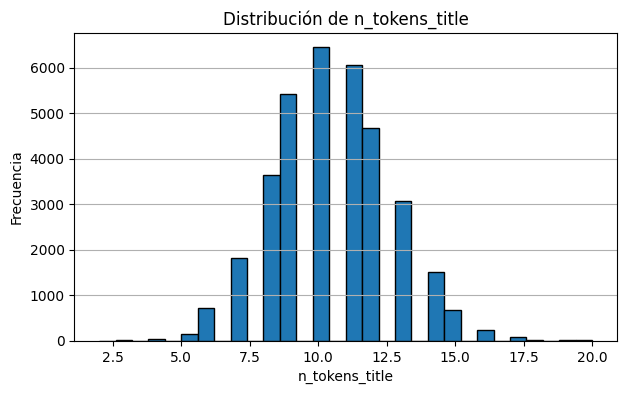

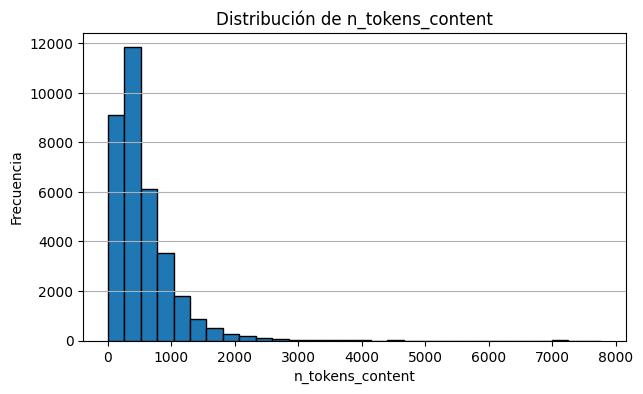

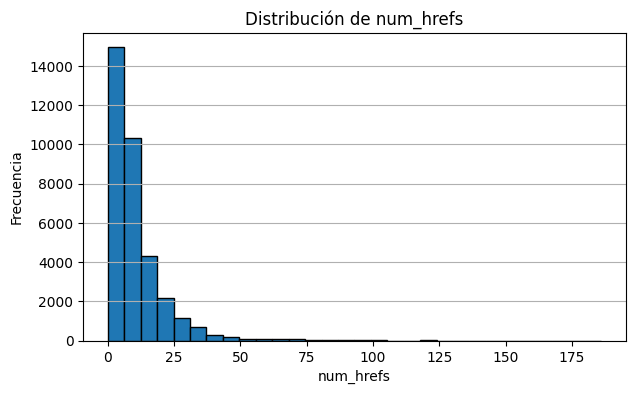

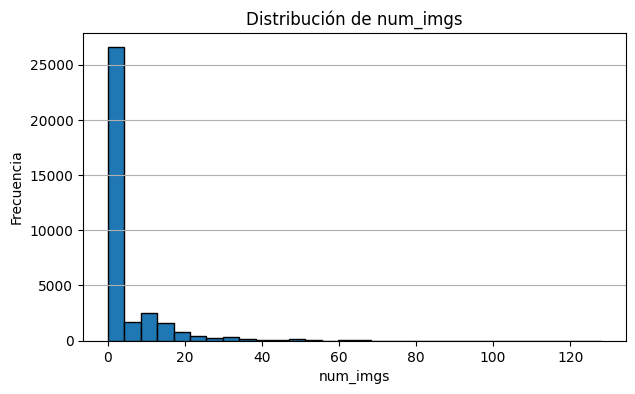

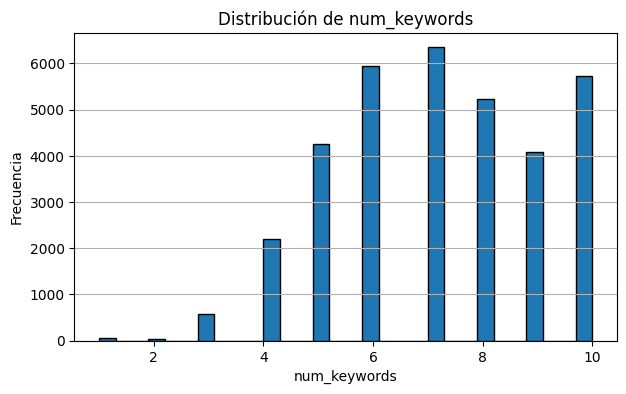

In [6]:
# PASO 7: Histogramas de las variables seleccionadas

for variable in variables_seleccionadas:
    plt.figure(figsize=(7, 4))
    plt.hist(df_model[variable], bins=30, edgecolor='black')
    plt.title(f'Distribución de {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y')
    plt.show()

### Interpretación de los histogramas

Los histogramas muestran la distribución de las cinco variables seleccionadas para el análisis.

A través de estos gráficos es posible identificar si los valores se concentran en rangos específicos, si existen valores extremos o si las variables presentan una distribución asimétrica.

Por ejemplo, variables como `num_hrefs` o `num_imgs` pueden presentar muchos artículos con pocos enlaces o pocas imágenes, y algunos artículos con valores más altos. En el caso de `n_tokens_content`, la distribución permite observar si la mayoría de los artículos tienen una extensión similar o si existen artículos mucho más largos que el promedio.

Este análisis visual complementa las estadísticas descriptivas calculadas anteriormente y permite comprender mejor el comportamiento de las variables antes de entrenar los modelos predictivos.

## 1.5 Análisis de correlaciones

En esta sección se calcula la matriz de correlación entre las cinco variables seleccionadas y la variable `shares`.

Además, se crea una versión numérica de la variable `Popularidad` solo para efectos exploratorios, donde `Menor = 0`, `Medio = 1` y `Superior = 2`.

El objetivo es observar si las variables seleccionadas presentan alguna relación lineal con la cantidad de veces que un artículo fue compartido o con su nivel de popularidad.

In [7]:
# PASO 8: Análisis de correlaciones

# Crear una copia para análisis de correlación
df_corr = df_model.copy()

# Codificar Popularidad solo para análisis exploratorio
df_corr['Popularidad_num'] = df_corr['Popularidad'].map({
    'Menor': 0,
    'Medio': 1,
    'Superior': 2
})

# Variables para matriz de correlación
variables_correlacion = variables_seleccionadas + ['shares', 'Popularidad_num']

# Calcular matriz de correlación
matriz_correlacion = df_corr[variables_correlacion].corr()

print("Matriz de correlación:")
display(matriz_correlacion.round(3))

print("\nCorrelación de las variables seleccionadas con shares:")
display(matriz_correlacion['shares'].sort_values(ascending=False).round(3))

print("\nCorrelación de las variables seleccionadas con Popularidad_num:")
display(matriz_correlacion['Popularidad_num'].sort_values(ascending=False).round(3))

Matriz de correlación:


,n_tokens_title,n_tokens_content,num_hrefs,num_imgs,num_keywords,shares,Popularidad_num
n_tokens_title,1.000,0.034,-0.039,0.002,0.000,-0.040,-0.048
n_tokens_content,0.034,1.000,0.426,0.359,0.067,0.043,0.050
num_hrefs,-0.039,0.426,1.000,0.343,0.124,0.075,0.080
num_imgs,0.002,0.359,0.343,1.000,0.079,0.052,0.050
num_keywords,0.000,0.067,0.124,0.079,1.000,0.063,0.061
shares,-0.040,0.043,0.075,0.052,0.063,1.000,0.834
Popularidad_num,-0.048,0.050,0.080,0.050,0.061,0.834,1.000



Correlación de las variables seleccionadas con shares:


shares              1.000
Popularidad_num     0.834
num_hrefs           0.075
num_keywords        0.063
num_imgs            0.052
n_tokens_content    0.043
n_tokens_title     -0.040
Name: shares, dtype: float64


Correlación de las variables seleccionadas con Popularidad_num:


Popularidad_num     1.000
shares              0.834
num_hrefs           0.080
num_keywords        0.061
n_tokens_content    0.050
num_imgs            0.050
n_tokens_title     -0.048
Name: Popularidad_num, dtype: float64

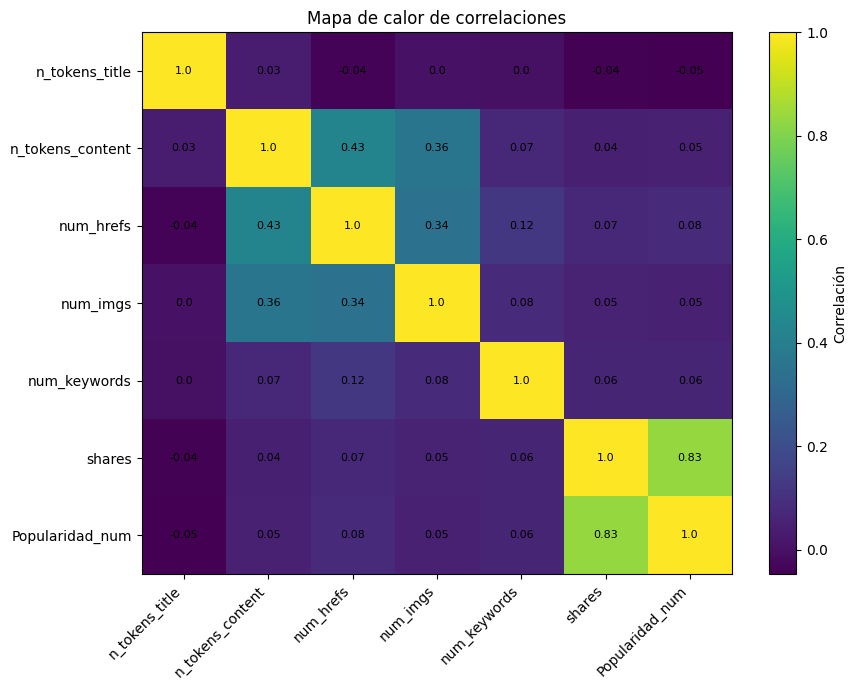

In [8]:
# PASO 8B: Mapa de calor de correlaciones

plt.figure(figsize=(9, 7))

plt.imshow(matriz_correlacion, aspect='auto')
plt.colorbar(label='Correlación')

plt.xticks(
    range(len(matriz_correlacion.columns)),
    matriz_correlacion.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(matriz_correlacion.columns)),
    matriz_correlacion.columns
)

plt.title('Mapa de calor de correlaciones')

# Agregar valores dentro del mapa
for i in range(len(matriz_correlacion.columns)):
    for j in range(len(matriz_correlacion.columns)):
        plt.text(
            j,
            i,
            round(matriz_correlacion.iloc[i, j], 2),
            ha='center',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

### Interpretación del resultado

La matriz de correlación permite observar la relación lineal entre las variables seleccionadas, la variable `shares` y la variable `Popularidad_num`.

Una correlación positiva indica que, cuando una variable aumenta, también tiende a aumentar la cantidad de veces que el artículo es compartido o su nivel de popularidad. Una correlación negativa indica una relación inversa. Una correlación cercana a cero indica que no existe una relación lineal clara.

La variable `Popularidad_num` fue creada solo para apoyar el análisis exploratorio, ya que la variable original `Popularidad` es categórica. Esta codificación permite revisar de manera aproximada si las variables seleccionadas se relacionan con el paso desde `Menor` hacia `Medio` y `Superior`.

Este análisis permite identificar preliminarmente qué variables podrían aportar mayor información al modelo de clasificación. Sin embargo, la correlación no implica causalidad y no necesariamente captura relaciones complejas o no lineales, por lo que posteriormente se entrenarán modelos como SVM, Regresión Logística y Random Forest.

## 1.6 Visualizaciones bivariadas con Popularidad

En esta sección se utilizan gráficos para explorar la relación entre las cinco variables seleccionadas y la popularidad de los artículos.

Se analizará la relación de cada variable con `shares`, que representa la cantidad de veces que un artículo fue compartido, y también con la variable categórica `Popularidad`, compuesta por las clases `Menor`, `Medio` y `Superior`.

Distribución de la variable Popularidad:


Popularidad
Menor       12424
Medio       11131
Superior    10909
Name: count, dtype: int64

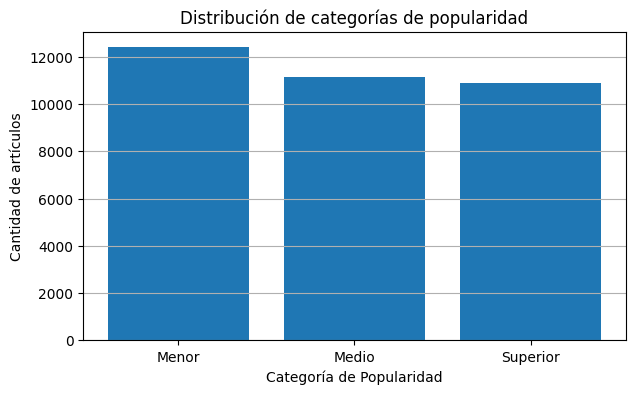

In [9]:
# PASO 9A: Distribución de la variable Popularidad

conteo_popularidad = df_model['Popularidad'].value_counts()

print("Distribución de la variable Popularidad:")
display(conteo_popularidad)

plt.figure(figsize=(7, 4))
plt.bar(conteo_popularidad.index, conteo_popularidad.values)
plt.title('Distribución de categorías de popularidad')
plt.xlabel('Categoría de Popularidad')
plt.ylabel('Cantidad de artículos')
plt.grid(axis='y')
plt.show()

### Interpretación del gráfico

El gráfico muestra la cantidad de artículos presentes en cada categoría de popularidad: `Menor`, `Medio` y `Superior`.

Esta revisión es importante porque permite observar si las clases están balanceadas o desbalanceadas. Si una categoría tiene muchos más registros que otra, el modelo podría aprender mejor la clase mayoritaria y tener más dificultad para clasificar correctamente las clases con menos observaciones.

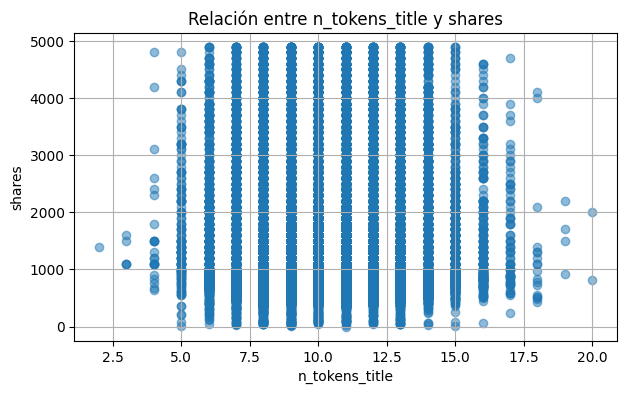

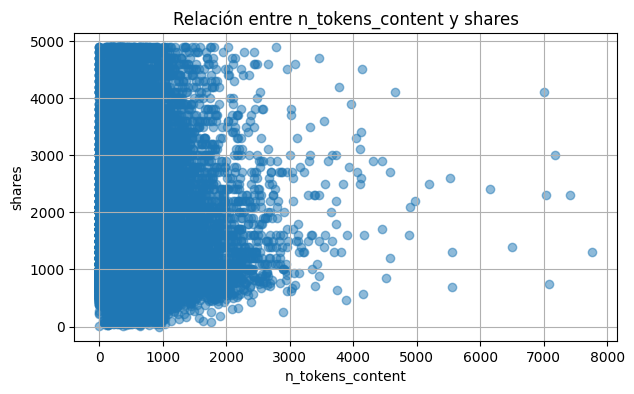

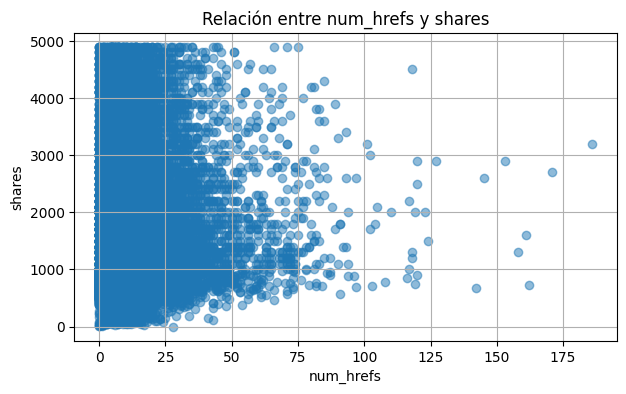

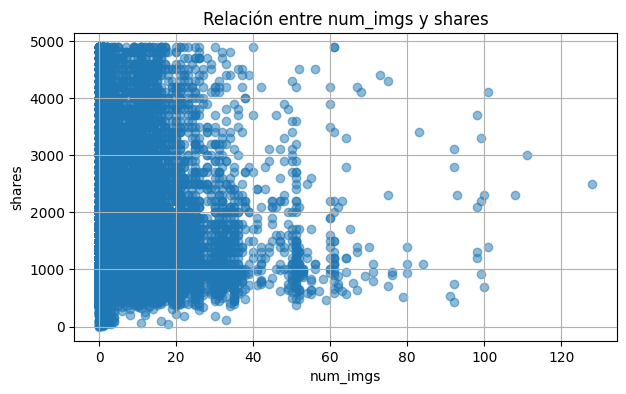

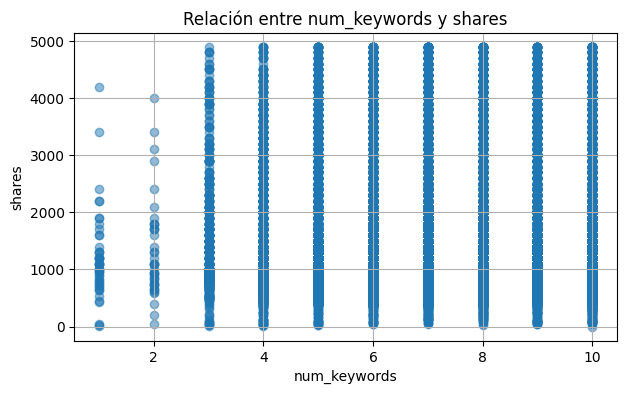

In [10]:
# PASO 9B: Gráficos de dispersión entre variables seleccionadas y shares

for variable in variables_seleccionadas:
    plt.figure(figsize=(7, 4))
    plt.scatter(df_model[variable], df_model['shares'], alpha=0.5)
    plt.title(f'Relación entre {variable} y shares')
    plt.xlabel(variable)
    plt.ylabel('shares')
    plt.grid(True)
    plt.show()

### Interpretación de los gráficos de dispersión

Los gráficos de dispersión permiten observar la relación entre cada variable seleccionada y la cantidad de veces que un artículo fue compartido.

Si los puntos muestran una tendencia ascendente, significa que a medida que aumenta la variable también tiende a aumentar la cantidad de compartidos. Si los puntos están muy dispersos, la relación puede ser débil o no lineal.

Este análisis ayuda a identificar si variables como cantidad de palabras del contenido, enlaces, imágenes o palabras clave podrían estar relacionadas con mayores niveles de popularidad.

/tmp/ipykernel_1232/1836663807.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=orden_categorias)


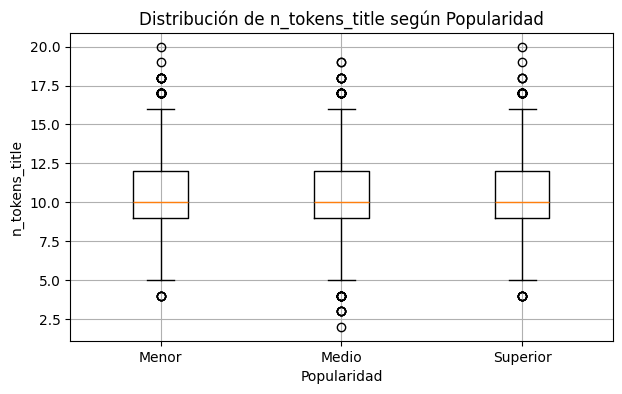

/tmp/ipykernel_1232/1836663807.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=orden_categorias)


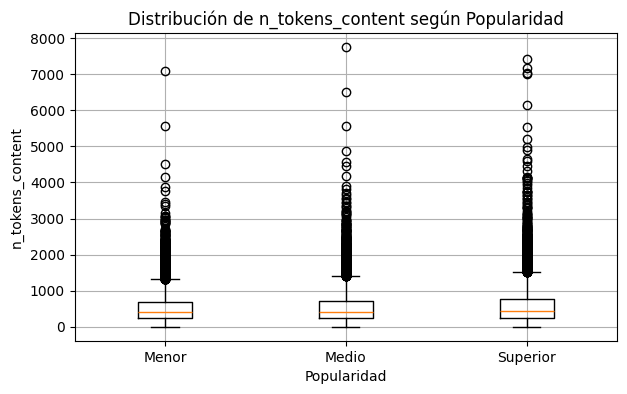

/tmp/ipykernel_1232/1836663807.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=orden_categorias)


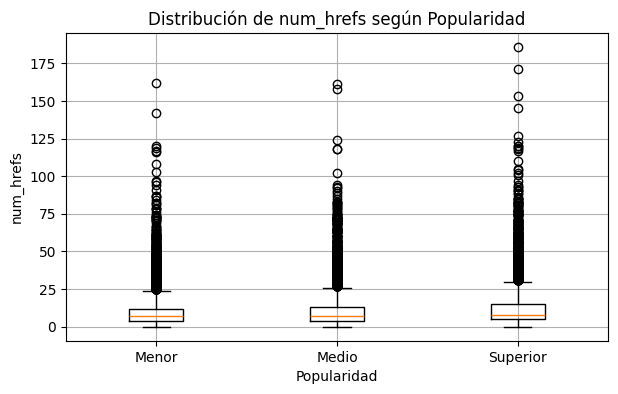

/tmp/ipykernel_1232/1836663807.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=orden_categorias)


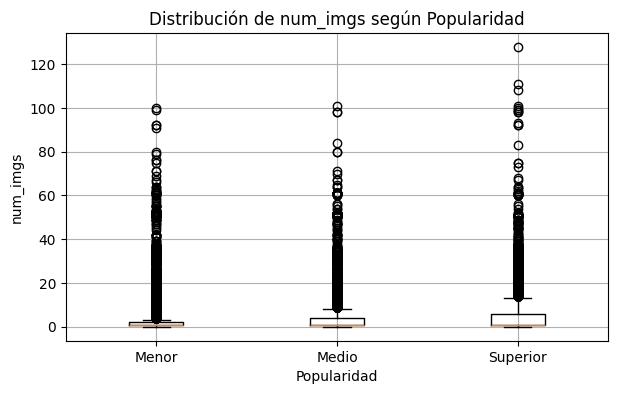

/tmp/ipykernel_1232/1836663807.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=orden_categorias)


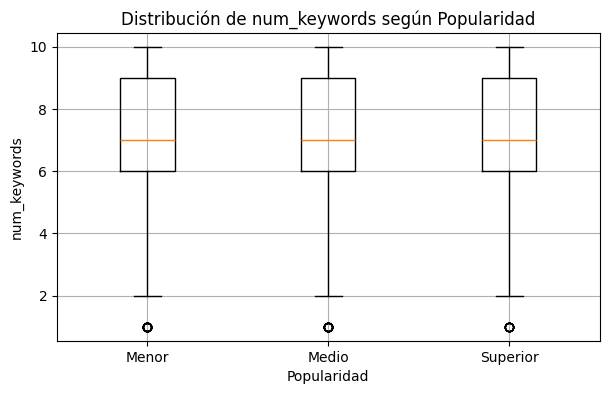

In [11]:
# PASO 9C: Boxplots de variables seleccionadas según Popularidad

orden_categorias = ['Menor', 'Medio', 'Superior']

for variable in variables_seleccionadas:
    datos_por_categoria = [
        df_model[df_model['Popularidad'] == categoria][variable]
        for categoria in orden_categorias
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(datos_por_categoria, labels=orden_categorias)
    plt.title(f'Distribución de {variable} según Popularidad')
    plt.xlabel('Popularidad')
    plt.ylabel(variable)
    plt.grid(True)
    plt.show()

### Interpretación de los boxplots

Los boxplots permiten comparar cómo se distribuyen las variables seleccionadas en cada categoría de popularidad.

Si una variable presenta valores claramente más altos o más bajos en la categoría `Superior`, podría ser una señal de que esa característica ayuda a diferenciar los artículos más compartidos.

En cambio, si las distribuciones son muy similares entre `Menor`, `Medio` y `Superior`, esa variable podría tener menor capacidad individual para separar las categorías de popularidad.

### Conclusión de la Actividad 1

En la Actividad 1 se realizó un análisis exploratorio de la base `OnlineNewsPopularity-3.csv`, considerando la selección de cinco variables relevantes para predecir la popularidad de los artículos.

Las variables seleccionadas fueron `n_tokens_title`, `n_tokens_content`, `num_hrefs`, `num_imgs` y `num_keywords`, ya que representan características estructurales del artículo que pueden influir en su alcance y probabilidad de ser compartido.

También se creó la variable objetivo `Popularidad`, agrupando la variable `shares` en tres categorías: `Menor`, `Medio` y `Superior`.

Luego se calcularon estadísticas descriptivas, histogramas, correlaciones, gráficos de dispersión y boxplots. Estos análisis permiten comprender mejor el comportamiento de las variables antes de entrenar los modelos de clasificación.

En conclusión, las variables seleccionadas entregan una primera aproximación al comportamiento de la popularidad de los artículos. Sin embargo, la relación entre las características del artículo y su popularidad puede ser compleja y no necesariamente lineal, por lo que resulta adecuado entrenar y comparar modelos como SVM, Regresión Logística y Random Forest.

# 2. División de datos y entrenamiento de modelos

## Instrucción de la actividad

En esta sección se divide la base en 70% para entrenamiento y 30% para test. Luego se entrenarán tres modelos de clasificación supervisada: SVM, Regresión Logística y Random Forest.

La variable objetivo será `Popularidad`, creada previamente a partir de la variable `shares`, con tres categorías: `Menor`, `Medio` y `Superior`.

Para el entrenamiento se utilizarán las variables predictoras disponibles en la base, excluyendo `url`, `shares` y `Popularidad`, ya que `shares` fue utilizada para construir la variable objetivo.

In [12]:
# PASO 10: Preparar datos para clasificación

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separar variable objetivo
y = df_model['Popularidad']

# Separar variables explicativas
# Se eliminan url, shares y Popularidad
columnas_eliminar = ['shares', 'Popularidad']

if 'url' in df_model.columns:
    columnas_eliminar.append('url')

X = df_model.drop(columns=columnas_eliminar)

# Mantener solo variables numéricas
X = X.select_dtypes(include=['int64', 'float64'])

# Codificar la variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases de popularidad codificadas:")
for clase, codigo in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{clase}: {codigo}")

print("\nDimensiones de X e y:")
print(f"X: {X.shape}")
print(f"y: {y_encoded.shape}")

print("\nPrimeras variables utilizadas:")
print(X.columns[:10].tolist())

Clases de popularidad codificadas:
Medio: 0
Menor: 1
Superior: 2

Dimensiones de X e y:
X: (34464, 59)
y: (34464,)

Primeras variables utilizadas:
['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos']


### Interpretación del resultado

En esta etapa se prepararon los datos para entrenar los modelos de clasificación.

La variable objetivo corresponde a `Popularidad`, que contiene las categorías `Menor`, `Medio` y `Superior`. Como los modelos de machine learning trabajan mejor con valores numéricos, esta variable fue codificada mediante `LabelEncoder`.

También se eliminaron las columnas `url`, `shares` y `Popularidad`. La columna `url` no aporta información numérica directa para el modelo, `shares` no debe usarse como variable predictora porque fue la base para crear la categoría de popularidad, y `Popularidad` corresponde a la variable objetivo.

Finalmente, se conservaron solo variables numéricas para entrenar los modelos SVM, Regresión Logística y Random Forest.

In [13]:
# PASO 11: Dividir datos en entrenamiento y test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Estandarización para SVM y Regresión Logística
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Registros de entrenamiento: {X_train.shape[0]}")
print(f"Registros de test: {X_test.shape[0]}")
print(f"Total de registros utilizados: {X_train.shape[0] + X_test.shape[0]}")

print("\nDistribución de clases en entrenamiento:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nDistribución de clases en test:")
print(pd.Series(y_test).value_counts().sort_index())

Registros de entrenamiento: 24124
Registros de test: 10340
Total de registros utilizados: 34464

Distribución de clases en entrenamiento:
0    7791
1    8697
2    7636
Name: count, dtype: int64

Distribución de clases en test:
0    3340
1    3727
2    3273
Name: count, dtype: int64


### Interpretación del resultado

En esta etapa la base fue dividida en 70% para entrenamiento y 30% para test, tal como solicita la actividad.

El conjunto de entrenamiento se utilizará para ajustar los modelos, mientras que el conjunto de test permitirá evaluar su rendimiento sobre datos no utilizados durante el entrenamiento.

Se utilizó `stratify=y_encoded` para mantener una proporción similar de las clases `Menor`, `Medio` y `Superior` tanto en entrenamiento como en test. Esto es importante en problemas de clasificación, especialmente cuando puede existir desbalance entre clases.

Además, se estandarizaron las variables explicativas para los modelos SVM y Regresión Logística, ya que estos modelos son sensibles a la escala de las variables.

## 2.1 Entrenamiento de modelos de clasificación

En esta sección se entrenan tres modelos de clasificación supervisada para predecir la variable `Popularidad`.

Los modelos utilizados son:

1. SVM, Support Vector Machine.
2. Regresión Logística.
3. Random Forest.

SVM y Regresión Logística se entrenan con variables estandarizadas, ya que son modelos sensibles a la escala de los datos. Random Forest se entrena con las variables originales, ya que este modelo basado en árboles no requiere estandarización.

In [14]:
# PASO 12: Entrenar tres modelos de clasificación

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: SVM
modelo_svm = LinearSVC(random_state=42, max_iter=5000)
modelo_svm.fit(X_train_scaled, y_train)

# Modelo 2: Regresión Logística
modelo_logistica = LogisticRegression(max_iter=2000, random_state=42)
modelo_logistica.fit(X_train_scaled, y_train)

# Modelo 3: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

print("Modelos entrenados correctamente:")
print("- SVM")
print("- Regresión Logística")
print("- Random Forest")

Modelos entrenados correctamente:
- SVM
- Regresión Logística
- Random Forest


### Interpretación del resultado

En esta etapa se entrenaron los tres modelos solicitados en la tarea: SVM, Regresión Logística y Random Forest.

El modelo SVM busca separar las clases de popularidad mediante un hiperplano de decisión. En este caso se utilizó una versión lineal para reducir el tiempo de procesamiento y facilitar la ejecución en Google Colab.

La Regresión Logística se utiliza como modelo de clasificación, aunque su nombre incluya la palabra “regresión”. Este modelo estima la probabilidad de pertenecer a cada clase de popularidad.

Random Forest combina múltiples árboles de decisión y clasifica los artículos mediante el voto conjunto de varios árboles. Este modelo suele ser útil cuando existen relaciones no lineales entre las variables.

Con los modelos ya entrenados, el siguiente paso será evaluar su rendimiento mediante métricas de clasificación como accuracy, precisión, recall y f1-score.

# 3. Evaluación de rendimiento de los modelos

## Instrucción de la actividad

En esta sección se evalúan los tres modelos entrenados: SVM, Regresión Logística y Random Forest.

La evaluación se realizará utilizando métricas de clasificación como accuracy, precision, recall y f1-score. Estas métricas permiten comparar el rendimiento de los modelos y determinar cuál clasifica mejor la popularidad de los artículos en las categorías `Menor`, `Medio` y `Superior`.

In [15]:
# PASO 13: Evaluar rendimiento de SVM, Regresión Logística y Random Forest

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Realizar predicciones con cada modelo
y_pred_svm = modelo_svm.predict(X_test_scaled)
y_pred_logistica = modelo_logistica.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

# Función para calcular métricas principales
def evaluar_clasificacion(nombre_modelo, y_real, y_pred):
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_real, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_real, y_pred, average='macro', zero_division=0)

    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'F1_macro': f1
    }

# Crear tabla comparativa
resultados_modelos = pd.DataFrame([
    evaluar_clasificacion('SVM', y_test, y_pred_svm),
    evaluar_clasificacion('Regresión Logística', y_test, y_pred_logistica),
    evaluar_clasificacion('Random Forest', y_test, y_pred_rf)
])

# Ordenar por F1-score macro
resultados_modelos = resultados_modelos.sort_values(
    by='F1_macro',
    ascending=False
).round(4)

print("Comparación de rendimiento de modelos:")
display(resultados_modelos)

# Identificar mejor modelo según F1_macro
mejor_modelo_nombre = resultados_modelos.iloc[0]['Modelo']

print(f"Mejor modelo según F1_macro: {mejor_modelo_nombre}")

Comparación de rendimiento de modelos:


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
2,Random Forest,0.4829,0.4695,0.4766,0.4689
1,Regresión Logística,0.4819,0.4660,0.4735,0.4484
0,SVM,0.4782,0.4606,0.4688,0.4254


Mejor modelo según F1_macro: Random Forest


In [16]:
# PASO 13B: Reporte detallado de clasificación por modelo

print("Reporte de clasificación - SVM")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nReporte de clasificación - Regresión Logística")
print(classification_report(
    y_test,
    y_pred_logistica,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nReporte de clasificación - Random Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

Reporte de clasificación - SVM
              precision    recall  f1-score   support

       Medio       0.42      0.11      0.17      3340
       Menor       0.49      0.74      0.59      3727
    Superior       0.47      0.56      0.51      3273

    accuracy                           0.48     10340
   macro avg       0.46      0.47      0.43     10340
weighted avg       0.46      0.48      0.43     10340


Reporte de clasificación - Regresión Logística
              precision    recall  f1-score   support

       Medio       0.42      0.18      0.25      3340
       Menor       0.50      0.71      0.59      3727
    Superior       0.48      0.53      0.51      3273

    accuracy                           0.48     10340
   macro avg       0.47      0.47      0.45     10340
weighted avg       0.47      0.48      0.45     10340


Reporte de clasificación - Random Forest
              precision    recall  f1-score   support

       Medio       0.38      0.29      0.33      3340
       M

### Interpretación del resultado

En esta etapa se evaluaron los tres modelos entrenados utilizando métricas de clasificación.

El `accuracy` indica la proporción total de artículos correctamente clasificados. Sin embargo, cuando las clases no están perfectamente balanceadas, esta métrica puede ser insuficiente por sí sola.

Por esta razón, también se utilizaron `precision`, `recall` y `f1-score` en promedio macro. El promedio macro calcula el rendimiento considerando cada clase por igual, independiente de la cantidad de registros que tenga cada categoría.

El `precision_macro` permite observar qué tan confiables son las predicciones positivas de cada clase. El `recall_macro` muestra la capacidad del modelo para detectar correctamente los casos reales de cada categoría. El `F1_macro` resume precision y recall en una sola métrica.

Para seleccionar el mejor modelo se utiliza principalmente `F1_macro`, ya que permite evaluar de forma más equilibrada el desempeño entre las categorías `Menor`, `Medio` y `Superior`.

## 3.1 Matriz de confusión e importancia de variables

En esta sección se complementa la evaluación de los modelos mediante matrices de confusión. Estas permiten observar cuántos artículos fueron clasificados correctamente y cuántos fueron confundidos entre las categorías `Menor`, `Medio` y `Superior`.

Además, se analiza la importancia de variables utilizando el modelo Random Forest, ya que este modelo permite identificar qué características tuvieron mayor peso en la predicción de la popularidad.

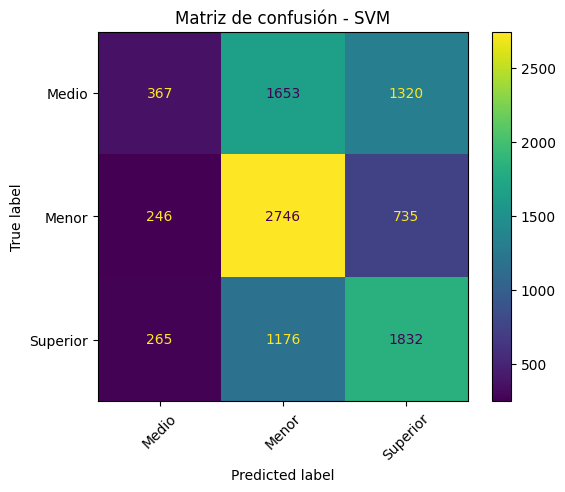

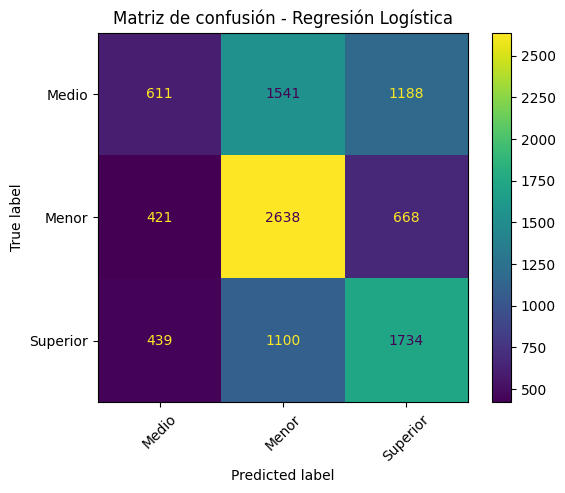

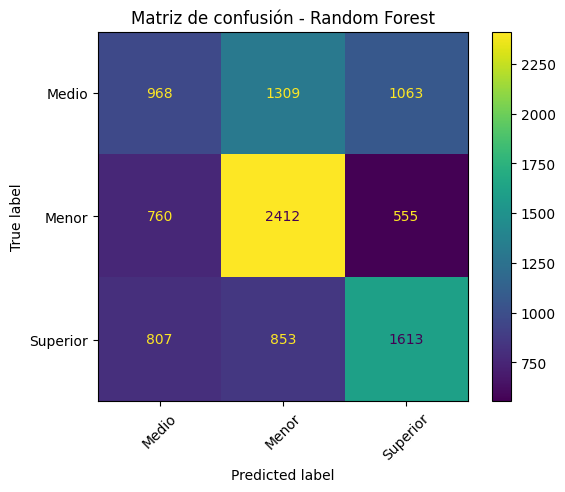

In [17]:
# PASO 14A: Matrices de confusión de los modelos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelos_predicciones = {
    'SVM': y_pred_svm,
    'Regresión Logística': y_pred_logistica,
    'Random Forest': y_pred_rf
}

for nombre_modelo, predicciones in modelos_predicciones.items():
    matriz = confusion_matrix(y_test, predicciones)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=label_encoder.classes_
    )

    disp.plot(xticks_rotation=45)
    plt.title(f'Matriz de confusión - {nombre_modelo}')
    plt.show()

### Interpretación de las matrices de confusión

Las matrices de confusión permiten observar el rendimiento de cada modelo por categoría de popularidad.

Los valores ubicados en la diagonal principal representan clasificaciones correctas. Los valores fuera de la diagonal muestran errores de clasificación, es decir, artículos que pertenecían a una categoría pero fueron clasificados en otra.

Este análisis es importante porque permite identificar si el modelo se equivoca más entre categorías cercanas, por ejemplo, confundiendo artículos `Medio` con `Superior`, o si presenta dificultades para reconocer alguna categoría específica.

Además, este análisis complementa las métricas de accuracy, precision, recall y f1-score, entregando una visión más detallada del comportamiento de los modelos.

In [18]:
# PASO 14B: Importancia de variables según Random Forest

importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by='Importancia',
    ascending=False
).round(4)

print("Variables más importantes según Random Forest:")
display(importancias_rf.head(15))

Variables más importantes según Random Forest:


,Variable,Importancia
26,kw_avg_avg,0.0354
25,kw_max_avg,0.0333
0,timedelta,0.0322
38,LDA_00,0.0293
40,LDA_02,0.0290
42,LDA_04,0.0289
39,LDA_01,0.0286
20,kw_avg_min,0.0284
23,kw_avg_max,0.0283
10,average_token_length,0.0274


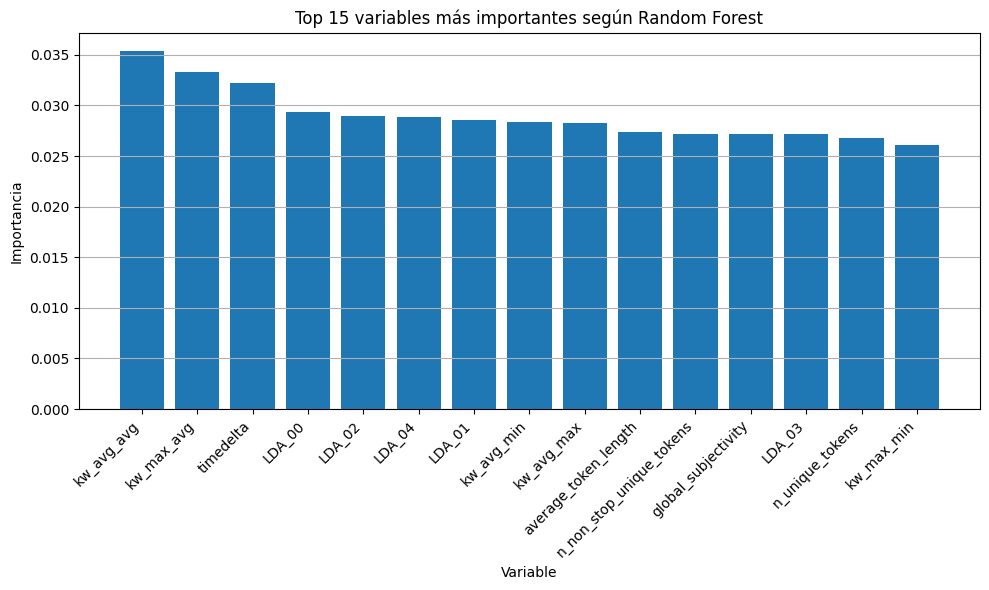

In [19]:
# PASO 14C: Gráfico de las 15 variables más importantes

top_importancias = importancias_rf.head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_importancias['Variable'], top_importancias['Importancia'])
plt.title('Top 15 variables más importantes según Random Forest')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Interpretación de la importancia de variables

El gráfico muestra las variables que tuvieron mayor importancia en el modelo Random Forest para predecir la categoría de popularidad de los artículos.

Las variables con mayor importancia son aquellas que el modelo utilizó con mayor peso para separar los artículos entre las clases `Menor`, `Medio` y `Superior`.

Este análisis permite comprender qué características del artículo aportan más información al proceso de clasificación. Variables relacionadas con palabras clave, enlaces, contenido, sentimiento, canal de publicación o referencias internas pueden influir en la predicción de la popularidad.

Es importante señalar que la importancia de variables en Random Forest no implica causalidad directa, sino que indica qué variables fueron más útiles para el modelo al momento de clasificar los artículos.

### Conclusión de la Actividad 3

En esta actividad se evaluaron los modelos SVM, Regresión Logística y Random Forest utilizando métricas de clasificación como accuracy, precision, recall y f1-score.

El mejor modelo se seleccionó principalmente según el valor de `F1_macro`, ya que esta métrica permite evaluar el equilibrio entre precision y recall considerando todas las clases por igual. Esto es importante porque, si las categorías de popularidad están desbalanceadas, el accuracy por sí solo puede entregar una visión incompleta del rendimiento del modelo.

Las matrices de confusión permitieron observar con mayor detalle los aciertos y errores de cada modelo, identificando posibles confusiones entre las categorías `Menor`, `Medio` y `Superior`.

Finalmente, se analizó la importancia de variables mediante Random Forest. Este análisis permitió identificar qué características de los artículos aportan mayor información para predecir su nivel de popularidad.

En conclusión, la comparación de modelos permite seleccionar la alternativa con mejor desempeño predictivo y, al mismo tiempo, comprender qué variables influyen más en la clasificación de la popularidad de los artículos.

# 4. Búsqueda por grilla para mejorar el mejor modelo

## Instrucción de la actividad

En esta sección se aplica búsqueda por grilla mediante `GridSearchCV` para ajustar los hiperparámetros del mejor modelo encontrado previamente.

El objetivo es mejorar el rendimiento del modelo seleccionado, utilizando como métrica principal `F1_macro`, ya que esta métrica permite evaluar de forma equilibrada el desempeño entre las categorías `Menor`, `Medio` y `Superior`.

In [20]:
# PASO 15: Búsqueda por grilla para el mejor modelo encontrado

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print(f"Mejor modelo inicial según F1_macro: {mejor_modelo_nombre}")

# Definir modelo base, grilla y datos según el mejor modelo encontrado
if mejor_modelo_nombre == 'SVM':
    modelo_base_grid = LinearSVC(random_state=42, max_iter=8000)
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced']
    }
    X_train_grid = X_train_scaled
    X_test_grid = X_test_scaled

elif mejor_modelo_nombre == 'Regresión Logística':
    modelo_base_grid = LogisticRegression(max_iter=3000, random_state=42)
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
        'solver': ['lbfgs']
    }
    X_train_grid = X_train_scaled
    X_test_grid = X_test_scaled

else:
    modelo_base_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None],
        'min_samples_split': [2],
        'class_weight': [None]
    }
    X_train_grid = X_train
    X_test_grid = X_test

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_base_grid,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=2,
    n_jobs=1
)

# Entrenar búsqueda por grilla
grid_search.fit(X_train_grid, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor F1_macro promedio en validación cruzada:")
print(round(grid_search.best_score_, 4))


Mejor modelo inicial según F1_macro: Random Forest


Mejores hiperparámetros encontrados:
{'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Mejor F1_macro promedio en validación cruzada:
0.4624


## 4.1 Evaluación del modelo optimizado

En esta sección se evalúa el modelo optimizado mediante GridSearchCV y se compara su rendimiento con el modelo inicial.

El objetivo es verificar si la búsqueda por grilla permitió mejorar el desempeño del mejor modelo encontrado previamente.

In [21]:
# PASO 16: Evaluar modelo optimizado y comparar con modelo inicial

# Mejor modelo encontrado por GridSearchCV
mejor_modelo_grid = grid_search.best_estimator_

# Predicciones del modelo optimizado
y_pred_grid = mejor_modelo_grid.predict(X_test_grid)

# Evaluar modelo optimizado
resultado_grid = pd.DataFrame([
    evaluar_clasificacion('Random Forest Optimizado', y_test, y_pred_grid)
]).round(4)

print("Resultado del modelo optimizado:")
display(resultado_grid)

print("\nResultados de modelos iniciales:")
display(resultados_modelos)

# Comparar con Random Forest inicial
f1_rf_inicial = resultados_modelos.loc[
    resultados_modelos['Modelo'] == 'Random Forest',
    'F1_macro'
].values[0]

f1_rf_optimizado = resultado_grid.loc[
    resultado_grid['Modelo'] == 'Random Forest Optimizado',
    'F1_macro'
].values[0]

print(f"F1_macro Random Forest inicial: {f1_rf_inicial:.4f}")
print(f"F1_macro Random Forest optimizado: {f1_rf_optimizado:.4f}")

if f1_rf_optimizado > f1_rf_inicial:
    print("Conclusión: el modelo optimizado mejoró su rendimiento.")
else:
    print("Conclusión: el modelo optimizado no mejoró el rendimiento del modelo inicial.")

Resultado del modelo optimizado:


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Random Forest Optimizado,0.4908,0.4762,0.4844,0.4746



Resultados de modelos iniciales:


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
2,Random Forest,0.4829,0.4695,0.4766,0.4689
1,Regresión Logística,0.4819,0.4660,0.4735,0.4484
0,SVM,0.4782,0.4606,0.4688,0.4254


F1_macro Random Forest inicial: 0.4689
F1_macro Random Forest optimizado: 0.4746
Conclusión: el modelo optimizado mejoró su rendimiento.


### Interpretación del resultado

En esta etapa se evaluó el modelo optimizado obtenido mediante GridSearchCV.

La comparación se realiza contra el modelo Random Forest inicial, utilizando principalmente la métrica `F1_macro`. Esta métrica permite evaluar el rendimiento promedio del modelo considerando todas las clases por igual.

Si el `F1_macro` del modelo optimizado es mayor que el del modelo inicial, se concluye que la búsqueda por grilla permitió mejorar el rendimiento. Si no mejora, se debe indicar de forma transparente que la configuración inicial tuvo mejor desempeño en el conjunto de test.

Esta comparación es importante porque un modelo puede obtener buen rendimiento en validación cruzada, pero no necesariamente mejorar en el conjunto de test.

## 4.2 Reporte detallado del modelo optimizado

En esta sección se presenta el reporte detallado del modelo optimizado mediante GridSearchCV. Además, se define cuál será el modelo final que se utilizará para el análisis ROC y AUC.

In [22]:
# PASO 17: Reporte detallado del modelo optimizado

print("Reporte de clasificación - Modelo optimizado")
print(classification_report(
    y_test,
    y_pred_grid,
    target_names=label_encoder.classes_,
    zero_division=0
))

# Definir modelo final para análisis posterior
# Si el modelo optimizado mejora, se utiliza el optimizado.
# Si no mejora, se mantiene el modelo inicial con mejor desempeño.
if f1_rf_optimizado >= f1_rf_inicial:
    modelo_final = mejor_modelo_grid
    X_test_final = X_test_grid
    X_train_final = X_train_grid
    nombre_modelo_final = 'Random Forest Optimizado'
    y_pred_final = y_pred_grid
else:
    modelo_final = modelo_rf
    X_test_final = X_test
    X_train_final = X_train
    nombre_modelo_final = 'Random Forest Inicial'
    y_pred_final = y_pred_rf

print(f"Modelo final seleccionado para análisis ROC/AUC: {nombre_modelo_final}")

Reporte de clasificación - Modelo optimizado
              precision    recall  f1-score   support

       Medio       0.39      0.28      0.33      3340
       Menor       0.53      0.66      0.59      3727
    Superior       0.51      0.51      0.51      3273

    accuracy                           0.49     10340
   macro avg       0.48      0.48      0.47     10340
weighted avg       0.48      0.49      0.48     10340

Modelo final seleccionado para análisis ROC/AUC: Random Forest Optimizado


### Interpretación del resultado

En esta etapa se revisó el reporte de clasificación del modelo optimizado mediante GridSearchCV.

El reporte permite observar el desempeño por cada categoría de popularidad, considerando precision, recall y f1-score.

Además, se definió el modelo final que será utilizado para el análisis ROC y AUC. Si el modelo optimizado presenta mejor o igual F1_macro que el modelo inicial, se utiliza el modelo optimizado. En caso contrario, se conserva el modelo inicial con mejor desempeño en test.

Esta decisión permite trabajar con el modelo que entrega el mejor rendimiento real sobre el conjunto de prueba.

### Conclusión de la Actividad 4

En esta actividad se aplicó búsqueda por grilla mediante GridSearchCV al mejor modelo encontrado previamente.

La búsqueda por grilla permitió probar distintas combinaciones de hiperparámetros y seleccionar aquella que obtuvo mejor rendimiento promedio mediante validación cruzada.

En este caso, el mejor modelo inicial fue Random Forest. GridSearchCV permitió ajustar parámetros como `n_estimators`, `max_depth` y `min_samples_split`.

Finalmente, se comparó el rendimiento del modelo inicial con el modelo optimizado utilizando F1_macro. Esta comparación permite verificar si la optimización efectivamente mejora la capacidad del modelo para clasificar artículos en las categorías `Menor`, `Medio` y `Superior`.


# 5. Curva ROC y AUC del modelo final

## Instrucción de la actividad

En esta sección se construye la curva ROC y se calcula el AUC del modelo final seleccionado.

Como el problema tiene tres categorías de popularidad (`Menor`, `Medio` y `Superior`), se utilizará un enfoque multiclase One-vs-Rest. Esto permite evaluar la capacidad del modelo para distinguir cada categoría frente al resto.

AUC macro del modelo final (Random Forest Optimizado): 0.6678


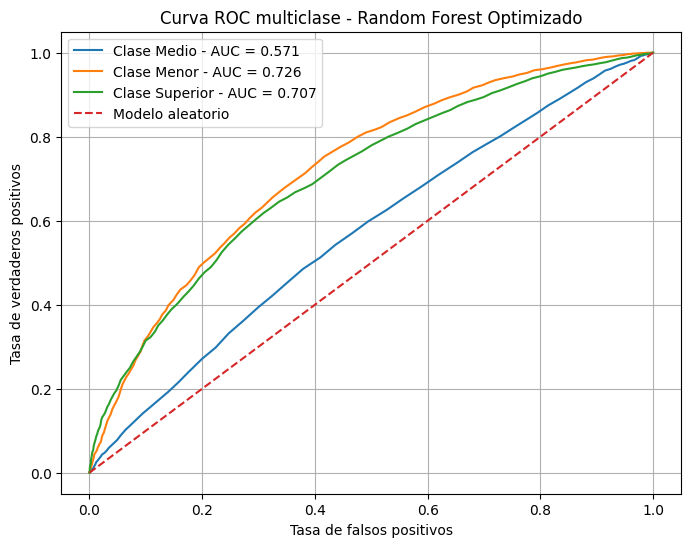

In [23]:
# PASO 18: Construir curva ROC y calcular AUC multiclase

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Binarizar variable objetivo para análisis ROC multiclase
clases = np.arange(len(label_encoder.classes_))
y_test_bin = label_binarize(y_test, classes=clases)

# Obtener probabilidades del modelo final
y_score = modelo_final.predict_proba(X_test_final)

# Calcular AUC macro multiclase
auc_macro = roc_auc_score(
    y_test_bin,
    y_score,
    average='macro',
    multi_class='ovr'
)

print(f"AUC macro del modelo final ({nombre_modelo_final}): {auc_macro:.4f}")

# Calcular curva ROC para cada clase
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar curvas ROC por clase
plt.figure(figsize=(8, 6))

for i, clase in enumerate(label_encoder.classes_):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Clase {clase} - AUC = {roc_auc[i]:.3f}'
    )

# Línea de referencia de modelo aleatorio
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo aleatorio')

plt.title(f'Curva ROC multiclase - {nombre_modelo_final}')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend()
plt.grid(True)
plt.show()

### Interpretación del resultado

En esta etapa se construyó la curva ROC del modelo final utilizando un enfoque multiclase One-vs-Rest.

La curva ROC permite evaluar la capacidad del modelo para distinguir correctamente cada clase de popularidad frente al resto de las categorías. En este caso, se analizan las clases `Menor`, `Medio` y `Superior`.

El AUC representa el área bajo la curva ROC. Un valor cercano a 1 indica una alta capacidad de separación entre clases, mientras que un valor cercano a 0.5 indica un rendimiento similar al azar.

La línea diagonal representa el comportamiento de un modelo aleatorio. Mientras más alejadas estén las curvas ROC por encima de esa línea, mejor será la capacidad predictiva del modelo.

Este análisis complementa las métricas de clasificación utilizadas anteriormente, ya que permite evaluar el rendimiento del modelo desde la perspectiva de la discriminación entre clases.

## 5.1 Análisis del rendimiento ROC/AUC y propuestas de mejora

En esta sección se analiza el rendimiento del modelo final a partir de la curva ROC y el valor AUC obtenido. Además, se proponen posibles mejoras para aumentar la capacidad predictiva del modelo.

In [24]:
# PASO 19: Resumen de AUC por clase

auc_por_clase = pd.DataFrame({
    'Clase': label_encoder.classes_,
    'AUC': [roc_auc[i] for i in range(len(label_encoder.classes_))]
}).round(4)

print("AUC por clase:")
display(auc_por_clase)

print(f"AUC macro del modelo final: {auc_macro:.4f}")
print(f"Modelo final evaluado: {nombre_modelo_final}")

AUC por clase:


,Clase,AUC
0,Medio,0.5706
1,Menor,0.7257
2,Superior,0.7071


AUC macro del modelo final: 0.6678
Modelo final evaluado: Random Forest Optimizado


### Interpretación del AUC

El AUC permite evaluar la capacidad del modelo para diferenciar entre las clases de popularidad. En este caso, se utilizó un enfoque multiclase One-vs-Rest, donde cada categoría se compara contra las demás.

Un AUC cercano a 1 indica una alta capacidad de separación entre clases, mientras que un AUC cercano a 0.5 indica un rendimiento similar al azar.

El AUC macro resume el rendimiento promedio del modelo considerando las tres categorías: `Menor`, `Medio` y `Superior`. Este valor permite analizar de forma general qué tan bien el modelo distingue entre los distintos niveles de popularidad.

Si alguna clase presenta un AUC menor que las demás, significa que el modelo tiene mayor dificultad para separar esa categoría frente al resto.

### Propuestas de mejora

A partir de los resultados obtenidos, se pueden considerar las siguientes acciones para mejorar el rendimiento del modelo:

1. **Ampliar la búsqueda de hiperparámetros**  
   Se podría aumentar la cantidad de combinaciones evaluadas en GridSearchCV, especialmente en Random Forest, probando más valores de `n_estimators`, `max_depth`, `min_samples_split` y `min_samples_leaf`.

2. **Revisar el balance de clases**  
   Si las categorías `Menor`, `Medio` y `Superior` presentan desbalance, se podrían aplicar técnicas de remuestreo, como oversampling, undersampling o SMOTE. Esto ayudaría a que el modelo aprenda mejor las clases con menos registros.

3. **Probar otros modelos de clasificación**  
   Se podrían evaluar modelos adicionales como Gradient Boosting, XGBoost o LightGBM, ya que suelen entregar buenos resultados en problemas con muchas variables numéricas.

4. **Usar selección de variables**  
   La base contiene muchas variables. Se podría realizar selección de características para eliminar variables poco relevantes o redundantes, reduciendo ruido y mejorando la capacidad de generalización del modelo.

5. **Crear nuevas variables explicativas**  
   Se podrían construir variables derivadas, por ejemplo, relación entre cantidad de imágenes y extensión del contenido, proporción de enlaces por cantidad de palabras o indicadores combinados de sentimiento y subjetividad.

6. **Ajustar los intervalos de popularidad**  
   La tarea presenta una inconsistencia en los rangos de `shares`, por lo que una mejora sería revisar los puntos de corte de las categorías usando criterios estadísticos, como terciles, percentiles o distribución real de los datos.

7. **Evaluar con validación cruzada más robusta**  
   Se podría utilizar una validación cruzada estratificada con más particiones para obtener una estimación más estable del rendimiento del modelo.

### Conclusión de la Actividad 5

En esta actividad se construyó la curva ROC y se calculó el AUC del modelo final seleccionado. Debido a que el problema considera tres categorías de popularidad, se utilizó un enfoque multiclase One-vs-Rest.

El análisis ROC/AUC permitió evaluar la capacidad del modelo para distinguir entre artículos de popularidad `Menor`, `Medio` y `Superior`. Este análisis complementa las métricas tradicionales de clasificación, como accuracy, precision, recall y f1-score.

En general, un mayor valor de AUC indica que el modelo tiene mejor capacidad para separar correctamente las clases. Sin embargo, si existen diferencias importantes entre los AUC de cada categoría, esto puede indicar que el modelo clasifica mejor algunas clases que otras.

Para mejorar el rendimiento, se recomienda ampliar la búsqueda de hiperparámetros, revisar el posible desbalance de clases, probar modelos adicionales, seleccionar variables más relevantes y construir nuevas variables explicativas asociadas a la estructura y contenido de los artículos.

En conclusión, la curva ROC y el AUC entregan una visión complementaria del rendimiento del modelo y permiten identificar oportunidades de mejora para futuras versiones del análisis.

# Resumen final de resultados

En esta sección se consolidan los principales resultados obtenidos durante la tarea. Se resumen los modelos entrenados, el mejor modelo inicial, el modelo optimizado mediante GridSearchCV, el rendimiento final mediante F1_macro y el análisis AUC.

In [25]:
# PASO 20: Resumen final de resultados

print("RESUMEN FINAL DE RESULTADOS")
print("---------------------------")

print("\nModelos iniciales evaluados:")
display(resultados_modelos)

print(f"\nMejor modelo inicial según F1_macro: {mejor_modelo_nombre}")

print("\nMejores hiperparámetros encontrados con GridSearchCV:")
print(grid_search.best_params_)

print(f"\nModelo final seleccionado: {nombre_modelo_final}")

print("\nReporte final del modelo seleccionado:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nAUC por clase:")
display(auc_por_clase)

print(f"\nAUC macro del modelo final: {auc_macro:.4f}")

print("\nTop 10 variables más importantes según Random Forest:")
display(importancias_rf.head(10))

RESUMEN FINAL DE RESULTADOS
---------------------------

Modelos iniciales evaluados:


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
2,Random Forest,0.4829,0.4695,0.4766,0.4689
1,Regresión Logística,0.4819,0.4660,0.4735,0.4484
0,SVM,0.4782,0.4606,0.4688,0.4254



Mejor modelo inicial según F1_macro: Random Forest

Mejores hiperparámetros encontrados con GridSearchCV:
{'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Modelo final seleccionado: Random Forest Optimizado

Reporte final del modelo seleccionado:
              precision    recall  f1-score   support

       Medio       0.39      0.28      0.33      3340
       Menor       0.53      0.66      0.59      3727
    Superior       0.51      0.51      0.51      3273

    accuracy                           0.49     10340
   macro avg       0.48      0.48      0.47     10340
weighted avg       0.48      0.49      0.48     10340


AUC por clase:


,Clase,AUC
0,Medio,0.5706
1,Menor,0.7257
2,Superior,0.7071



AUC macro del modelo final: 0.6678

Top 10 variables más importantes según Random Forest:


,Variable,Importancia
26,kw_avg_avg,0.0354
25,kw_max_avg,0.0333
0,timedelta,0.0322
38,LDA_00,0.0293
40,LDA_02,0.0290
42,LDA_04,0.0289
39,LDA_01,0.0286
20,kw_avg_min,0.0284
23,kw_avg_max,0.0283
10,average_token_length,0.0274


### Interpretación del resumen final

El resumen final permite visualizar de forma consolidada los principales resultados obtenidos en la tarea.

Primero se muestran los modelos iniciales evaluados: SVM, Regresión Logística y Random Forest. Luego se identifica el mejor modelo según `F1_macro`, métrica que permite evaluar el desempeño promedio considerando todas las clases por igual.

También se presentan los mejores hiperparámetros encontrados mediante GridSearchCV y el modelo final seleccionado para el análisis ROC/AUC.

Finalmente, se muestra el AUC por clase, el AUC macro y las variables más importantes según Random Forest. Estos resultados permiten interpretar tanto el rendimiento predictivo del modelo como las características que más aportan a la clasificación de la popularidad de los artículos.

# Conclusión general de la Tarea de Acción 7

En esta tarea se desarrolló un proceso completo de análisis y modelamiento para clasificar la popularidad de artículos publicados en internet, utilizando la base `OnlineNewsPopularity-3.csv`.

Primero, se realizó un análisis exploratorio de la base de datos. Se seleccionaron cinco variables relevantes para analizar la popularidad de los artículos: `n_tokens_title`, `n_tokens_content`, `num_hrefs`, `num_imgs` y `num_keywords`. Estas variables fueron escogidas porque representan características estructurales del artículo que pueden influir en su capacidad de atraer lectores y ser compartido.

Luego, la variable `shares`, que representa la cantidad de veces que un artículo fue compartido, fue transformada en una variable categórica llamada `Popularidad`, compuesta por tres clases: `Menor`, `Medio` y `Superior`.

Posteriormente, se dividió la base en 70% para entrenamiento y 30% para test. Se entrenaron tres modelos de clasificación supervisada: SVM, Regresión Logística y Random Forest. Estos modelos fueron evaluados mediante métricas de clasificación como accuracy, precision, recall y f1-score.

El mejor modelo fue seleccionado principalmente según `F1_macro`, ya que esta métrica permite evaluar de manera equilibrada el rendimiento entre las tres clases de popularidad. Además, se analizaron matrices de confusión para observar los aciertos y errores de clasificación por categoría.

Luego, se aplicó búsqueda por grilla mediante GridSearchCV para mejorar el rendimiento del mejor modelo encontrado. Esta etapa permitió ajustar hiperparámetros y comparar el desempeño del modelo inicial frente al modelo optimizado.

Finalmente, se construyó la curva ROC multiclase y se calculó el AUC utilizando el enfoque One-vs-Rest. Este análisis permitió evaluar la capacidad del modelo para distinguir entre las categorías `Menor`, `Medio` y `Superior`.

En conclusión, Random Forest resultó ser un modelo adecuado para este problema, ya que permite trabajar con múltiples variables, capturar relaciones no lineales y analizar la importancia de las características predictoras. Sin embargo, el rendimiento podría mejorar mediante una búsqueda más amplia de hiperparámetros, revisión del balance de clases, selección de variables, creación de nuevas variables explicativas y prueba de modelos adicionales.